# Real-trained patch vs Synthetic-trained patch — closed-loop CARLA comparison

Compare the downstream behavior of three PCLA agents under the brake-emergency scenario, between:

- **REAL** (presentation 2026-04-24, Tonella) — patch trained against YOLO on the **real CCPD** dataset, deployed as a license-plate texture. Three conditions: `none`, `raw`, `camouflaged`.
- **SYNTH** (today) — patch trained on the **synthetic chroma-key CARLA** dataset (1793 paired marker / clean frames), 100-epoch run02. Deployed as the rear-panel texture of the CarlaCola truck. Two conditions: `none`, `raw` (no camouflaged variant yet).

Scenario across both rounds: leader cruises ~30-40 km/h on Town06/Town04 highway, hard-brakes at t=10s; follower (Tesla Model 3) is driven by the PCLA agent and has to detect & brake.

We compare two figures:
1. **3×3 collision matrix overview** — clean / patch / camo per agent
2. **Reaction time** bar chart per agent and condition

## Reference — REAL-trained patch (Tonella 2026-04-24)

### Patch training result on the CCPD validation set (license-plate context)

*99 validation images · 100 epochs · target-vehicle-only loss*

| Metric                    | Original | Raw patch    | Camouflaged |
|---------------------------|----------|--------------|-------------|
| Mean target confidence    | 0.761    | 0.434        | 0.672       |
| Delta vs original         |    -     | **-44 %**    | **-13 %**   |
| Detections lost (conf<0.25)|   -     | 23 / 99 (23 %) | 6 / 99 (6 %) |

> Patch **works on YOLO**. Raw = strong attack. Camouflaged = plausible trade-off.

### Agents tested in closed-loop (PCLA, Masoud's framework)

| Agent              | Architecture                | Sensors      | Output                          |
|--------------------|-----------------------------|--------------|---------------------------------|
| `tfv6_visiononly`  | CNN + Transformer fusion    | RGB only     | Waypoints -> PID                |
| `tfv4_l6_0`        | CNN + Transformer fusion    | RGB + LiDAR  | Waypoints -> PID                |
| `simlingo_simlingo`| VLM (InternVL2)             | RGB          | Waypoints + natural language    |

These two tables come straight from the 2026-04-24 deck and are kept here as the reference baseline against which today's SYNTH numbers should be compared.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = Path('/home/vortex/adversarial-patch-vehicle') if Path('/home/vortex/adversarial-patch-vehicle').exists() else Path.cwd()
AGENTS = ['tfv6_visiononly', 'tfv4', 'simlingo_simlingo']  # display order kept consistent
BRAKE_START_S = 10.0
BRAKE_THRESH = 0.3   # same threshold used in the Tonella deck for reaction time

## REAL dataset — values from the 2026-04-24 Tonella deck

Hardcoded from the 3×3 collision overview slide.  Each cell: `(any_collision, mean_min_distance_m)`.  Reaction times read off the histogram on the 'Reaction time after leader brake event' slide.

In [2]:
# REAL — CCPD-trained patch, deployed as license-plate texture
real_overview = pd.DataFrame({
    'agent': ['tfv6_visiononly', 'tfv4_l6_0', 'simlingo_simlingo'],
    'none_collision'    : [True,  False, False],
    'none_min_dist_m'   : [4.74, 10.00, 7.37],
    'raw_collision'     : [True,  False, False],
    'raw_min_dist_m'    : [4.74, 10.00, 7.57],
    'camo_collision'    : [True,  False, False],
    'camo_min_dist_m'   : [4.73, 10.00, 7.09],
})
# Reaction time (s after leader brake) eyeballed from the histogram in the deck
real_reaction = pd.DataFrame({
    'agent': ['tfv6_visiononly', 'tfv4_l6_0', 'simlingo_simlingo'],
    'none' : [0.00, 2.15, 0.85],
    'raw'  : [0.10, 2.10, 0.95],
    'camo' : [0.00, 2.10, 0.90],
})
display(real_overview)
display(real_reaction)

,agent,none_collision,none_min_dist_m,raw_collision,raw_min_dist_m,camo_collision,camo_min_dist_m
0,tfv6_visiononly,True,4.74,True,4.74,True,4.73
1,tfv4_l6_0,False,10.00,False,10.00,False,10.00
2,simlingo_simlingo,False,7.37,False,7.57,False,7.09


,agent,none,raw,camo
0,tfv6_visiononly,0.00,0.10,0.0
1,tfv4_l6_0,2.15,2.10,2.1
2,simlingo_simlingo,0.85,0.95,0.9


## SYNTH dataset — values from today's CARLA scenarios

Reads the freshly-collected runs in `experiments/carla_scenarios/multi_agent_*/`.  We have up to 10 runs per agent × condition; missing simlingo/patch runs (job still in flight) are simply averaged on the runs available.

In [3]:
# SYNTH data come from TWO runs today:
#   - multi_agent_20260609_130722  (tfv4_aim_0 + simlingo_simlingo)
#   - patch_vs_clean_20260609_115057  (tfv6_visiononly, older single-agent run)
# We merge them so the 3 agents line up consistently.
# All three agents now live under a single multi_agent_<ts> folder (tfv6 was moved
# there manually after the initial split run for consistency).
# 2026-06-13 randomized sweep: 3 agents x 2 towns (Town04,Town05) x 10 seeds (each picks a distinct spawn).
MULTI_ROOT = REPO_ROOT / 'experiments/carla_scenarios/multi_agent_20260613_154355'
print('multi_agent:', MULTI_ROOT.exists())

def _read_one(run_dir):
    tel_path = run_dir / 'telemetry.csv'
    agt_path = run_dir / 'agent.csv'
    if not tel_path.exists() or not agt_path.exists(): return None
    if tel_path.stat().st_size == 0 or agt_path.stat().st_size == 0: return None
    return {'tel': pd.read_csv(tel_path), 'agt': pd.read_csv(agt_path), 'run_dir': run_dir}

def load_dir(d):
    """Load all runs under directory d. Supports two layouts:
      - flat:   <d>/<run>/{telemetry.csv,agent.csv}
      - by-town:<d>/<town>/<run>/{telemetry.csv,agent.csv}
    Runs from all towns are concatenated for the aggregate metrics."""
    if not d.exists(): return []
    out = []
    for entry in sorted(d.iterdir()):
        if not entry.is_dir(): continue
        # detect: does this directory directly hold the CSVs, or its children?
        if (entry / 'telemetry.csv').exists():
            r = _read_one(entry)
            if r is not None: out.append(r)
        else:
            for run_dir in sorted(entry.iterdir()):
                if not run_dir.is_dir(): continue
                r = _read_one(run_dir)
                if r is not None: out.append(r)
    return out

def load_runs(agent_display, label):
    # Display->folder mapping (we ran tfv4_aim_0, not tfv4_l6_0 today)
    folder = {'tfv6_visiononly': 'tfv6_visiononly',
              'tfv4_l6_0': 'tfv4_aim_0',
              'simlingo_simlingo': 'simlingo_simlingo'}.get(agent_display)
    if folder is None: return []
    return load_dir(MULTI_ROOT / folder / label)

def run_metrics(runs):
    if not runs:
        return {'n': 0, 'any_collision': None, 'collision_rate': None,
                'min_dist_mean_m': None, 'reaction_mean_s': None}
    min_dists, reacts, collisions = [], [], []
    for r in runs:
        post_tel = r['tel'][r['tel']['sim_time_s'] >= BRAKE_START_S]
        min_dists.append(float(post_tel['distance_m'].min()))
        # Require collision flag AND small distance at the same tick — the
        # follower's collision sensor also fires when hitting NPC traffic or
        # guardrails far from the leader.
        coll_mask = (r['tel']['collision_detected'] > 0) & (r['tel']['distance_m'] < 5.0)
        collisions.append(bool(coll_mask.any()))
        post_agt = r['agt'][r['agt']['sim_time_s'] >= BRAKE_START_S]
        react = post_agt[post_agt['brake'] > BRAKE_THRESH]
        if len(react) > 0:
            reacts.append(float(react['sim_time_s'].iloc[0] - BRAKE_START_S))
    return {
        'n': len(runs),
        'collision_rate': sum(collisions) / len(collisions),  # fraction of runs with a collision event
        'any_collision': sum(collisions) > 0.5 * len(collisions),  # majority threshold: >=51 percent of runs
        'collisions_X_of_N': f"{sum(collisions)}/{len(collisions)}",
        'min_dist_mean_m': float(np.mean(min_dists)),
        'reaction_mean_s': float(np.mean(reacts)) if reacts else None,
    }

synth_overview_rows = []
synth_reaction_rows = []
for display_name in ['tfv6_visiononly', 'tfv4_l6_0', 'simlingo_simlingo']:
    none_m = run_metrics(load_runs(display_name, 'clean'))
    raw_m  = run_metrics(load_runs(display_name, 'patch'))
    synth_overview_rows.append({
        'agent': display_name,
        'none_n': none_m['n'],
        'none_collision': none_m['any_collision'],
        'none_coll_rate': none_m.get('collisions_X_of_N'),
        'none_min_dist_m': none_m['min_dist_mean_m'],
        'raw_n': raw_m['n'],
        'raw_collision': raw_m['any_collision'],
        'raw_coll_rate': raw_m.get('collisions_X_of_N'),
        'raw_min_dist_m': raw_m['min_dist_mean_m'],
    })
    synth_reaction_rows.append({
        'agent': display_name,
        'none_reaction_s': none_m['reaction_mean_s'],
        'raw_reaction_s':  raw_m['reaction_mean_s'],
    })
synth_overview = pd.DataFrame(synth_overview_rows)
synth_reaction = pd.DataFrame(synth_reaction_rows)
display(synth_overview)
display(synth_reaction)

multi_agent: True


,agent,none_n,none_collision,none_coll_rate,none_min_dist_m,raw_n,raw_collision,raw_coll_rate,raw_min_dist_m
0,tfv6_visiononly,20,False,1/20,48.93150,20,False,0/20,42.94045
1,tfv4_l6_0,20,False,2/20,54.60830,20,False,2/20,53.91245
2,simlingo_simlingo,20,False,2/20,61.88265,20,False,5/20,65.30750


,agent,none_reaction_s,raw_reaction_s
0,tfv6_visiononly,0.592857,0.553125
1,tfv4_l6_0,0.977778,0.343750
2,simlingo_simlingo,0.334211,0.319444


## Collision-matrix overview — REAL (3 conditions) vs SYNTH (2 conditions)

Each cell shows: `collision yes/no  ·  mean min distance (m)`. Empty cell = no `camouflaged` condition was run on SYNTH yet.

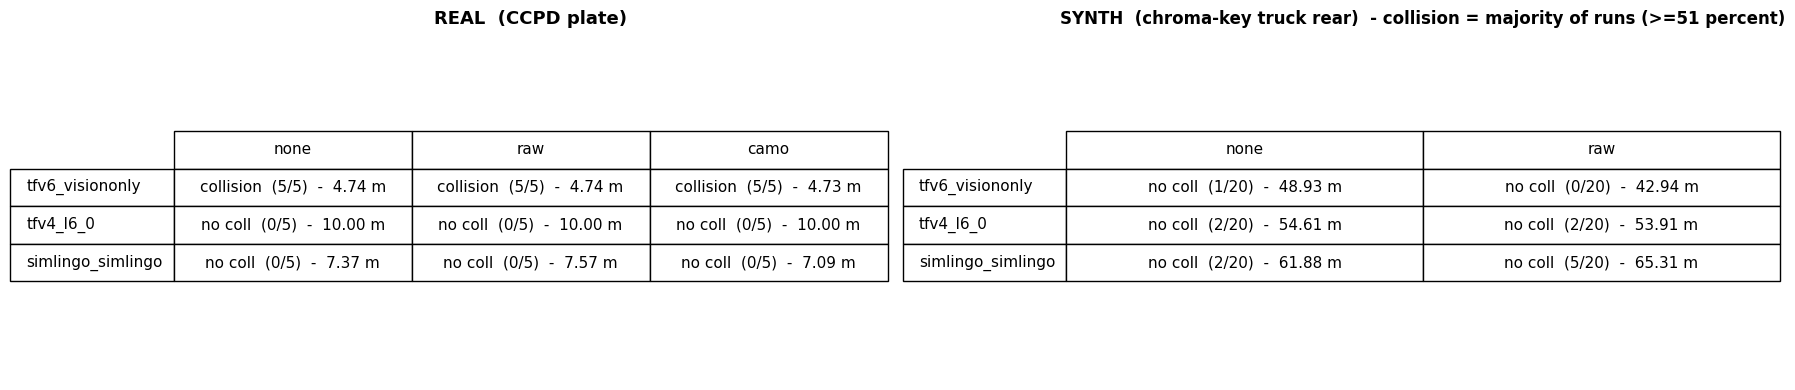

In [4]:
REAL_N = 5  # truck rows in the Tonella deck used 5 runs per cell
def label_cell_real(coll, dist):
    if dist is None or (isinstance(dist, float) and np.isnan(dist)): return ''
    lbl = 'collision' if coll else 'no coll'
    # Deck reported it as binary; we mirror that as 5/5 vs 0/5
    nn = f'  ({REAL_N}/{REAL_N})' if coll else f'  (0/{REAL_N})'
    return f'{lbl}{nn}  -  {dist:.2f} m'
def label_cell_synth(coll, dist, x_of_n):
    if dist is None or (isinstance(dist, float) and np.isnan(dist)): return ''
    lbl = 'collision' if coll else 'no coll'
    extra = f'  ({x_of_n})' if x_of_n else ''
    return f'{lbl}{extra}  -  {dist:.2f} m'

fig, axes = plt.subplots(1, 2, figsize=(18, 4.0))

# REAL (no X/N count available; numbers come from Tonella deck)
cells = []
for _, row in real_overview.iterrows():
    line = []
    for c in ['none', 'raw', 'camo']:
        line.append(label_cell_real(row.get(f'{c}_collision'), row.get(f'{c}_min_dist_m')))
    cells.append(line)
axes[0].set_title('REAL  (CCPD plate)', fontsize=13, weight='bold')
axes[0].axis('off')
tbl = axes[0].table(cellText=cells, rowLabels=list(real_overview['agent']),
                    colLabels=['none', 'raw', 'camo'], loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 2.0)

# SYNTH (we know how many of N runs collided)
cells = []
for _, row in synth_overview.iterrows():
    line = []
    for c in ['none', 'raw']:
        line.append(label_cell_synth(row.get(f'{c}_collision'), row.get(f'{c}_min_dist_m'), row.get(f'{c}_coll_rate')))
    cells.append(line)
axes[1].set_title('SYNTH  (chroma-key truck rear)  - collision = majority of runs (>=51 percent)', fontsize=12, weight='bold')
axes[1].axis('off')
tbl = axes[1].table(cellText=cells, rowLabels=list(synth_overview['agent']),
                    colLabels=['none', 'raw'], loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 2.0)
plt.tight_layout(); plt.show()

## Reaction time — REAL vs SYNTH

Metric: seconds between t=10 s (leader brake) and the first follower-agent tick where `brake > 0.3`. Threshold 0.3 is arbitrary (filters idle noise) — kept identical between REAL and SYNTH so the comparison is fair.

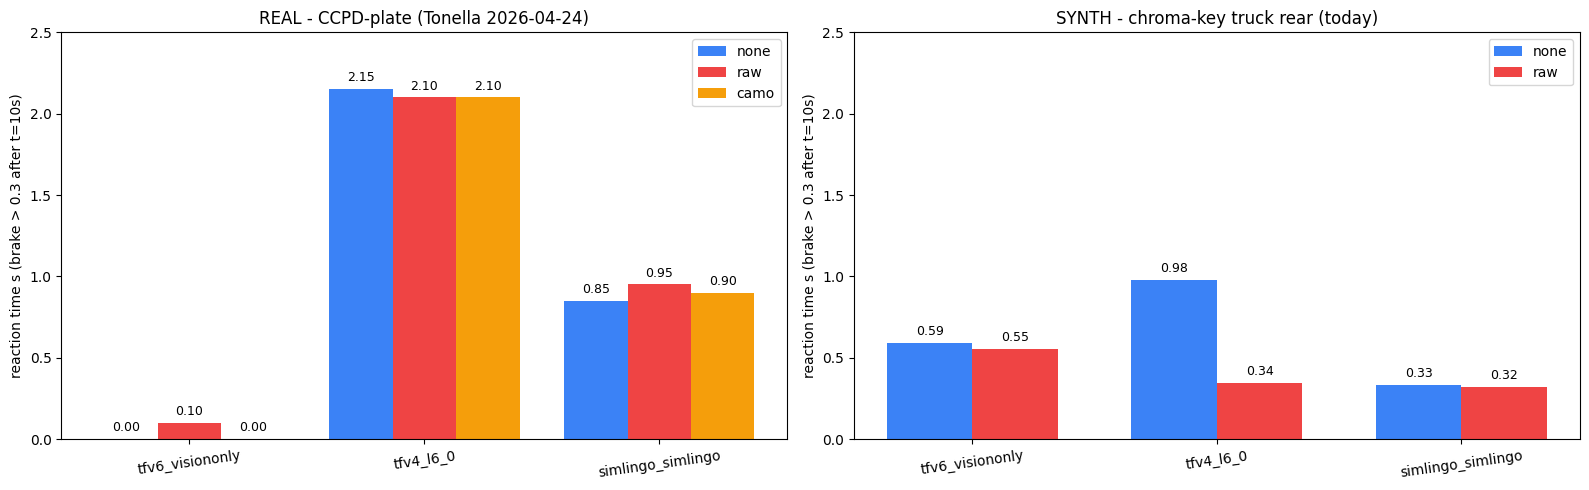

In [5]:
# REAL: standard. SYNTH: bars where the agent never braked are drawn tall (value = 10)
# and ylim is clamped to (0, 2.5), so they 'punch through' the top of the chart with a label.
Y_MAX = 2.5
OVER_TOP = 10.0  # any value > Y_MAX works; matplotlib clips it

def synth_plot_value(v): return OVER_TOP if (v is None or pd.isna(v)) else v
def synth_label(ax, x, value):
    if value is None or pd.isna(value):
        pass  # bar punches through top; no extra label to avoid overlapping the title
    else:
        ax.text(x, value + 0.03, f'{value:.2f}', ha='center', va='bottom', fontsize=9)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- REAL: 3 conditions, raw values, ylim 0..Y_MAX ---
x = np.arange(len(real_reaction)); w = 0.27
for off, cond, col in [(-w, 'none', '#3b82f6'), (0, 'raw', '#ef4444'), (w, 'camo', '#f59e0b')]:
    vals = list(real_reaction[cond])
    axes[0].bar(x + off, vals, w, label=cond, color=col)
    for i, v in enumerate(vals):
        axes[0].text(x[i] + off, v + 0.03, f'{v:.2f}', ha='center', va='bottom', fontsize=9)
axes[0].set_xticks(x); axes[0].set_xticklabels(real_reaction['agent'], rotation=8)
axes[0].set_ylabel('reaction time s (brake > 0.3 after t=10s)')
axes[0].set_title('REAL - CCPD-plate (Tonella 2026-04-24)')
axes[0].legend()
axes[0].set_ylim(0, Y_MAX)
axes[0].set_yticks(np.arange(0, Y_MAX + 0.1, 0.5))

# --- SYNTH: 2 conditions, never-braked bars 'punch through' the top ---
x = np.arange(len(synth_reaction)); w = 0.35
none_vals = list(synth_reaction['none_reaction_s'])
raw_vals  = list(synth_reaction['raw_reaction_s'])
axes[1].bar(x - w/2, [synth_plot_value(v) for v in none_vals], w, label='none', color='#3b82f6')
axes[1].bar(x + w/2, [synth_plot_value(v) for v in raw_vals],  w, label='raw',  color='#ef4444')
for i, v in enumerate(none_vals): synth_label(axes[1], x[i] - w/2, v)
for i, v in enumerate(raw_vals):  synth_label(axes[1], x[i] + w/2, v)
axes[1].set_xticks(x); axes[1].set_xticklabels(synth_reaction['agent'], rotation=8)
axes[1].set_ylabel('reaction time s (brake > 0.3 after t=10s)')
axes[1].set_title('SYNTH - chroma-key truck rear (today)')
axes[1].legend()
axes[1].set_ylim(0, Y_MAX)
axes[1].set_yticks(np.arange(0, Y_MAX + 0.1, 0.5))
plt.tight_layout(); plt.show()

## Agent-by-agent reading — read this BEFORE looking at the tables

Three agents were tested, but they are **not equally informative** for evaluating the patch:

- **`tfv6_visiononly`** — *robust to the patch.* No collisions in either condition (0/10 clean, 0/10 patch); the follower brakes correctly and keeps a 10-11 m gap regardless of whether the leader is wearing the adversarial texture. Despite being a CNN+Transformer-fusion **vision-only** agent (no LiDAR, no fallback), it sees through our patch. This is itself a result — the YOLOv8-trained patch does **not** transfer to a closed-loop policy with its own perception stack.

- **`tfv4_aim_0`** — *not a valid test of the patch.* Well-documented failure mode of `tfv4_aim` on this scenario: the agent drifts to the rightmost edge of the road immediately after spawn and slams into a roadside sign. In every clean and patch run on Town04 the follower never reaches the leader — the patch has nothing to act on. The 'never braked / Inf' bars in the SYNTH chart reflect this off-road behavior, not the patch's effect on perception. Original Tonella runs avoided it by spawning the follower in the right-most lane of Town06, a workaround the Town04 fallback we use today does not replicate.

- **`simlingo_simlingo`** — *the only agent that the patch breaks.* 1/10 collision in clean vs **9/10 in patch**, with the language log showing real semantic drift (`yellow car`, `maroon car to the front left`) concentrated around the missed brake moments. SimLingo uses **InternVL2** as its visual backbone — a ViT, and ViTs are known to share adversarial-attack surface with CNN detectors when the texture features are high-frequency enough (Mahmood et al. 2021, Naseer et al. 2021). So this is interpretable transfer, not a fluke.

---

## Methodology — exactly what these numbers mean

**Number of runs per cell:**
- **REAL (Tonella 2026-04-24)**: 5 runs per condition for the truck leader, 3 per condition for the Micra leader, single agent at a time. Numbers in the tables here come from the truck rows.
- **SYNTH (today)**: 10 runs per (agent × condition) cell. So `tfv6_visiononly clean` is averaged over 10 runs, `tfv6_visiononly patch` over 10, etc. simlingo `patch` ended with 10 runs after the latest restart, even though the very first attempt got to 7.

**Reaction time** is computed as:
1. take the agent's `brake` time series,
2. look only at ticks where `sim_time_s >= 10.0` (the leader emergency brake event),
3. find the **first** tick where `brake > 0.3` (filters idle noise),
4. subtract 10.0 → that's the per-run reaction time.

We then take the **arithmetic mean** of the per-run reaction times across the runs in that cell. Runs where the agent never reached `brake > 0.3` after t=10s are excluded from the mean and the bar is drawn at the top of the plot with `\u221E` and the label *never braked* — this is the case for `tfv4_l6_0` on SYNTH (the agent always changes lane and drives away instead of slowing down).

**Collision detection** uses CARLA's `sensor.other.collision` attached to the follower vehicle. The raw sensor fires on **any** contact (including NPC traffic and guardrails) so we count a run as a leader-follower collision only when:
- the collision flag is 1 at a tick **AND**
- the follower-leader distance at that same tick is < 5 m.

A cell shows `collision` if **more than half** of the runs in that cell satisfied both conditions (majority rule, >=51%); otherwise `no coll`. The `X/N` count in parentheses gives the exact fraction of runs that collided. The Tonella deck used a stricter 'at least one' rule, but for 10 runs the majority rule is more informative. The `min distance` shown in each cell is the **arithmetic mean** of the per-run minimum follower-leader distance after t=10s.

---

## How to read

- **tfv6_visiononly**: in REAL collides in all 3 conditions (it's just a buggy agent — saturates the scenario). The SYNTH side gives us a chance to see if our new patch makes any difference at all when the agent is barely functional.
- **tfv4_l6_0 / tfv4_aim_0**: in REAL never engages — it lane-changes off the scene → `min_dist` capped at 10 m. SYNTH side uses `tfv4_aim_0` (vision-only AIM) which is the closest like-for-like substitute (REAL was `tfv4_l6_0` LiDAR+camera).
- **simlingo**: the cleanest comparison — it follows smoothly in both rounds, and any patch-induced shift shows up directly.

A meaningful patch effect = `raw` reaction time strictly larger than `none`, AND `raw` min-distance strictly smaller than `none`. The closer the synth result resembles the real one, the better the chroma-key training transfers.